In [36]:
import warnings
import pandas as pd
import numpy as np
import xarray as xr
import pystac_client
import planetary_computer
from pathlib import Path
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", "invalid value", RuntimeWarning)


In [37]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

collection = catalog.get_collection("terraclimate")

asset = collection.assets["zarr-abfs"]

open_kwargs = asset.extra_fields["xarray:open_kwargs"]

ds_tc = xr.open_dataset(
    asset.href,
    **open_kwargs
)

print(ds_tc)


<xarray.Dataset> Size: 2TB
Dimensions:  (time: 768, lat: 4320, lon: 8640, crs: 1)
Coordinates:
  * crs      (crs) int16 2B 3
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
  * time     (time) datetime64[ns] 6kB 1958-01-01 1958-02-01 ... 2021-12-01
Data variables: (12/14)
    aet      (time, lat, lon) float32 115GB dask.array<chunksize=(12, 1024, 1024), meta=np.ndarray>
    def      (time, lat, lon) float32 115GB dask.array<chunksize=(12, 1024, 1024), meta=np.ndarray>
    pdsi     (time, lat, lon) float32 115GB dask.array<chunksize=(12, 1024, 1024), meta=np.ndarray>
    pet      (time, lat, lon) float32 115GB dask.array<chunksize=(12, 1024, 1024), meta=np.ndarray>
    ppt      (time, lat, lon) float64 229GB dask.array<chunksize=(12, 1024, 1024), meta=np.ndarray>
    q        (time, lat, lon) float64 229GB dask.array<chunksize=(12, 1024, 1024), meta=np.ndarray>
    ...       ...
   

In [38]:
MY_BBOX = [36.013414, 1.2755, 38.960949, 4.459143]

ds_subset = ds_tc.sel(
    lon=slice(MY_BBOX[0], MY_BBOX[2]),
    lat=slice(MY_BBOX[3], MY_BBOX[1]),
    time=slice("2008-01-01", "2020-12-31")
)


In [39]:
vars_needed = ["soil", "ppt", "pdsi", "vpd"]

ds_subset = ds_subset[vars_needed]


In [40]:
ds_mean = ds_subset.mean(dim=["lat", "lon"])

ds_mean = ds_mean.compute()


In [41]:
df_tc = ds_mean.to_dataframe().reset_index()

df_tc["year"] = df_tc["time"].dt.year
df_tc["month"] = df_tc["time"].dt.month

df_tc.head()


,time,soil,ppt,pdsi,vpd,year,month
0,2008-01-01,2.952521,11.909340,-1.427885,2.435356,2008,1
1,2008-02-01,2.754559,4.569681,-2.393128,2.405926,2008,2
2,2008-03-01,2.598128,67.232524,-1.300200,1.979116,2008,3
3,2008-04-01,2.462639,60.557283,-2.252270,1.522956,2008,4
4,2008-05-01,2.350890,39.879059,-2.506431,1.540589,2008,5


In [42]:
DATA_DIR = Path(
    "/Users/skylarwang/Documents/GitHub/ucb/spring 26/livestock_mortality/IBLIData_CSV_PublicZipped"
)

losses = pd.read_csv(DATA_DIR / "livestock_losses_processed.csv")

losses["year"] = pd.to_numeric(losses["year"], errors="coerce")
losses["month"] = pd.to_numeric(losses["month"], errors="coerce")

losses = losses.dropna(subset=["year", "month", "tlu_loss"])

mort_monthly = (
    losses
    .groupby(["year", "month"], as_index=False)
    .agg(
        tlu_loss=("tlu_loss", "sum"),
        events=("tlu_loss", "count")
    )
)

mort_monthly.head()


,year,month,tlu_loss,events
0,2007.0,7.0,0.3,1
1,2007.0,8.0,0.5,1
2,2008.0,1.0,0.9,2
3,2008.0,2.0,0.6,2
4,2008.0,3.0,0.0,1


In [43]:
import requests
import pandas as pd

bbox = [36.013414, 1.2755, 38.960949, 4.459143]

url = "https://planetarycomputer.microsoft.com/api/data/v1/collections/terraclimate/cube"

payload = {
    "bbox": bbox,
    "datetime": "2008-01-01/2020-12-31",
    "variables": ["soil", "ppt", "pdsi", "vpd"],
    "aggregation": {
        "time": "mean",
        "space": "mean"
    }
}

response = requests.post(url, json=payload)

data = response.json()


In [44]:
data = mort_monthly.merge(
    df_tc,
    on=["year", "month"],
    how="left"
)

data.sort_values(["year", "month"], inplace=True)

data.head()


,year,month,tlu_loss,events,time,soil,ppt,pdsi,vpd
0,2007.0,7.0,0.3,1,NaT,NaN,NaN,NaN,NaN
1,2007.0,8.0,0.5,1,NaT,NaN,NaN,NaN,NaN
2,2008.0,1.0,0.9,2,2008-01-01,2.952521,11.909340,-1.427885,2.435356
3,2008.0,2.0,0.6,2,2008-02-01,2.754559,4.569681,-2.393128,2.405926
4,2008.0,3.0,0.0,1,2008-03-01,2.598128,67.232524,-1.300200,1.979116


In [45]:
data.describe().T


,count,mean,min,25%,50%,75%,max,std
year,95.0,2012.052632,2007.0,2009.0,2011.0,2013.5,2020.0,3.624293
month,95.0,6.378947,1.0,3.5,6.0,9.0,12.0,3.393294
tlu_loss,95.0,175.898947,0.0,52.9,107.8,234.45,907.6,192.547138
events,95.0,151.4,1.0,101.0,140.0,196.5,475.0,96.845831
time,93,2012-08-09 14:42:34.838709760,2008-01-01 00:00:00,2009-12-01 00:00:00,2011-11-01 00:00:00,2014-10-01 00:00:00,2020-12-01 00:00:00,NaN
soil,93.0,6.05881,1.271516,2.223517,3.459785,7.135267,35.993515,6.263125
ppt,93.0,33.397414,1.003799,6.196553,16.810915,44.156579,195.012936,38.907131
pdsi,93.0,0.582008,-3.08689,-1.599831,0.021824,2.564494,6.68263,2.551678
vpd,93.0,1.879462,1.479855,1.628883,1.812807,2.092793,2.709913,0.309667


In [46]:
data.isna().mean().sort_values(ascending=False)


time        0.021053
soil        0.021053
ppt         0.021053
pdsi        0.021053
vpd         0.021053
year        0.000000
month       0.000000
tlu_loss    0.000000
events      0.000000
dtype: float64

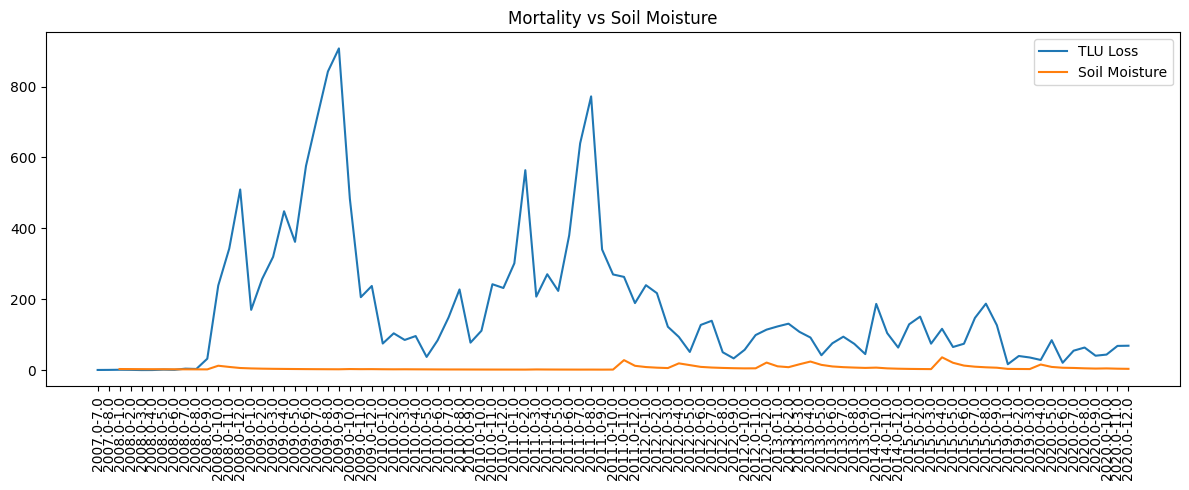

In [47]:
plt.figure(figsize=(12,5))

x_axis = data["year"].astype(str) + "-" + data["month"].astype(str)

plt.plot(x_axis, data["tlu_loss"], label="TLU Loss")
plt.plot(x_axis, data["soil"], label="Soil Moisture")

plt.xticks(rotation=90)
plt.legend()
plt.title("Mortality vs Soil Moisture")
plt.tight_layout()
plt.show()


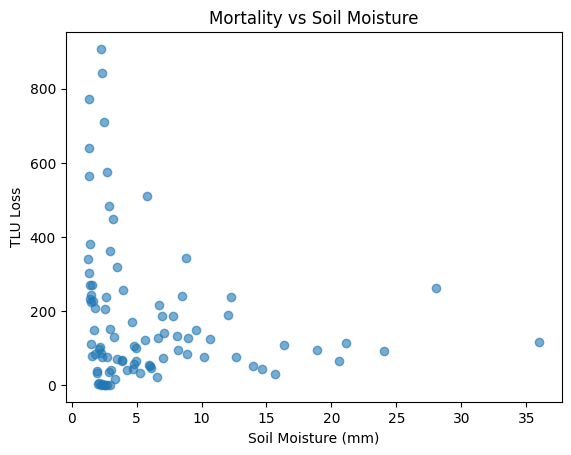

In [48]:
plt.scatter(data["soil"], data["tlu_loss"], alpha=0.6)
plt.xlabel("Soil Moisture (mm)")
plt.ylabel("TLU Loss")
plt.title("Mortality vs Soil Moisture")
plt.show()


In [57]:
data["soil_3mo_mean"] = data["soil"].rolling(3).mean()
data["rain_3mo_sum"] = data["ppt"].rolling(3).sum()


In [58]:
for lag in [1, 3, 6]:
    data[f"soil_lag_{lag}"] = data["soil"].shift(lag)
    data[f"rain_lag_{lag}"] = data["ppt"].shift(lag)


In [59]:
data["soil_z"] = (
    data["soil"] - data["soil"].mean()
) / data["soil"].std()


In [60]:
data["dry_signal"] = (
    (data["soil"] < data["soil"].quantile(0.2)) &
    (data["ppt"] < data["ppt"].quantile(0.2))
)

data.groupby("dry_signal")["tlu_loss"].mean()


dry_signal
False    176.260674
True     170.533333
Name: tlu_loss, dtype: float64

In [61]:
model_data = data.dropna().copy()

features = [
    "soil",
    "soil_3mo_mean",
    "ppt",
    "rain_3mo_sum",
    "pdsi",
    "vpd",
    "soil_z"
]

X = model_data[features]
y = model_data["tlu_loss"]

print("Final dataset shape:", X.shape)


Final dataset shape: (87, 7)


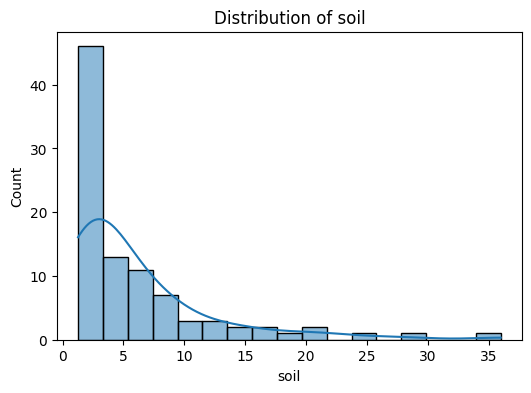

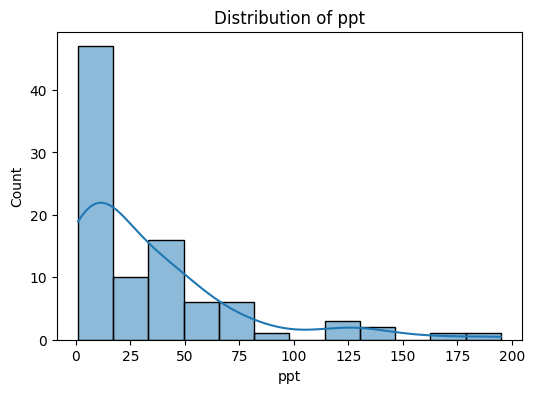

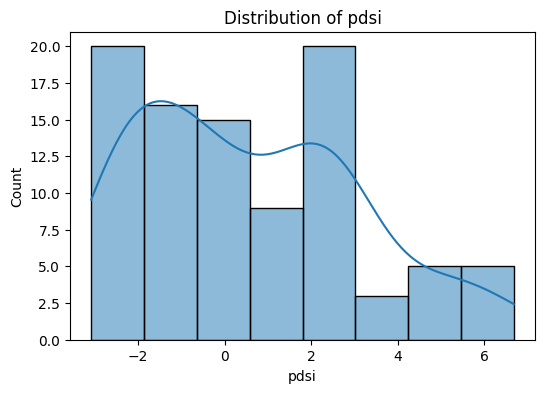

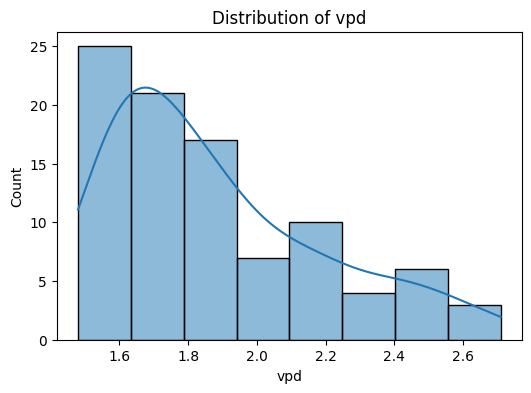

In [62]:
import seaborn as sns

climate_vars = ["soil", "ppt", "pdsi", "vpd"]

for var in climate_vars:
    plt.figure(figsize=(6,4))
    sns.histplot(data[var], kde=True)
    plt.title(f"Distribution of {var}")
    plt.show()


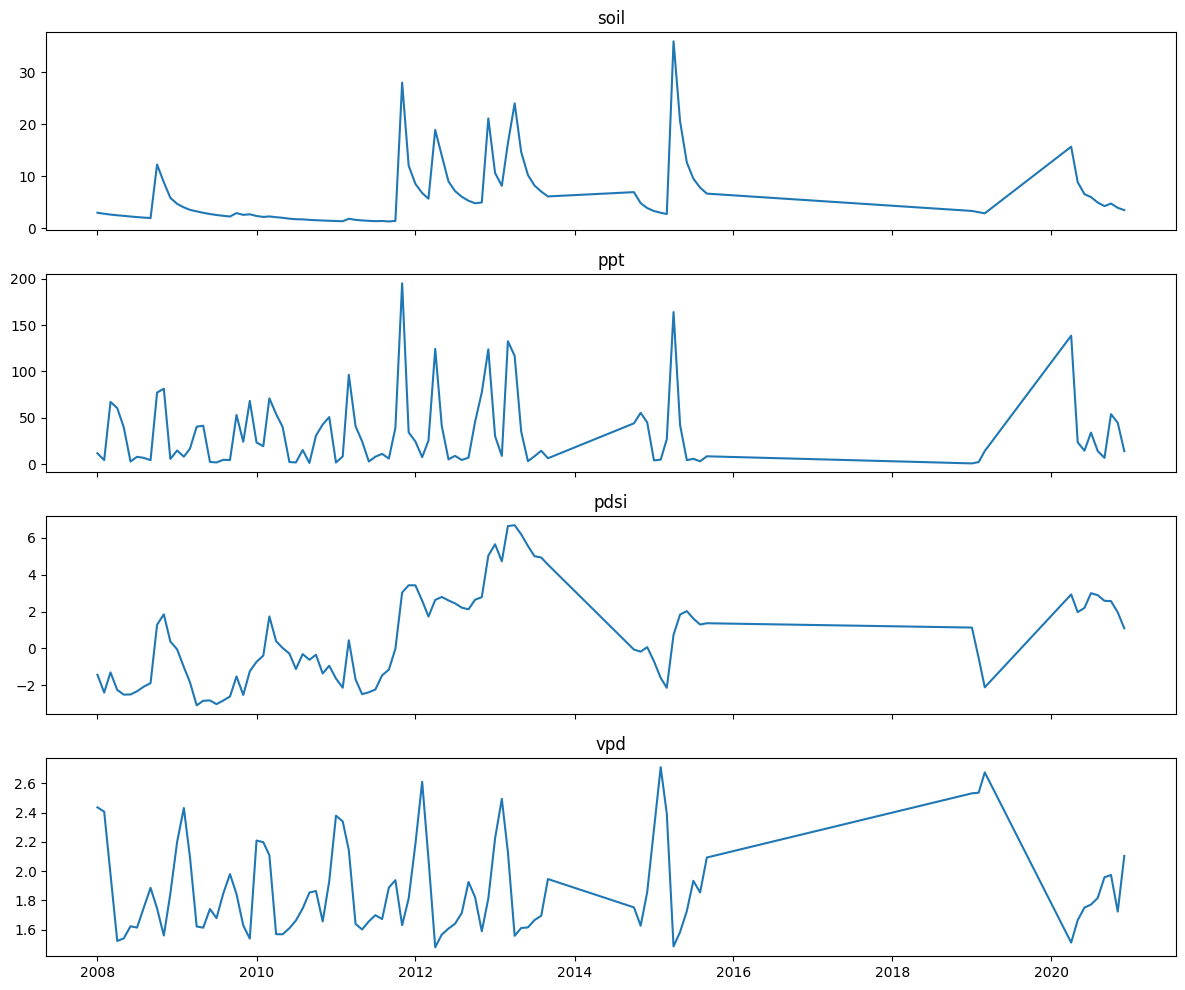

In [63]:
fig, axes = plt.subplots(4, 1, figsize=(12,10), sharex=True)

for i, var in enumerate(climate_vars):
    axes[i].plot(data["time"], data[var])
    axes[i].set_title(var)

plt.tight_layout()
plt.show()


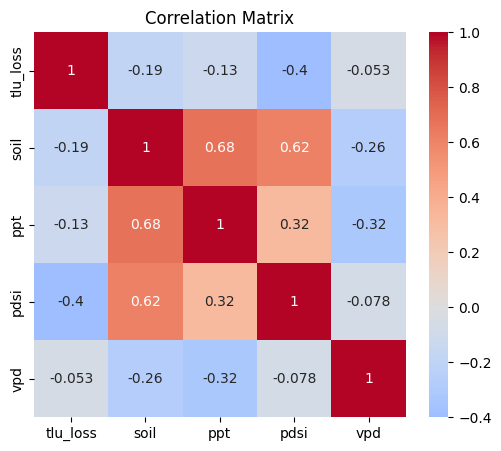

In [64]:
corr = data[["tlu_loss"] + climate_vars].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


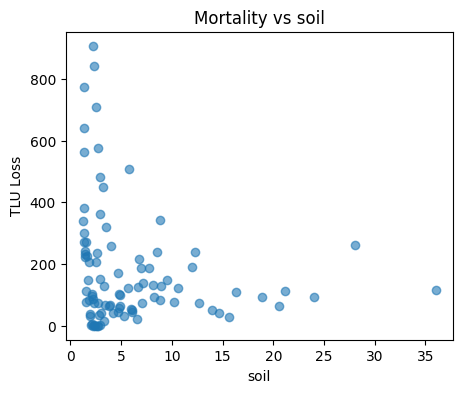

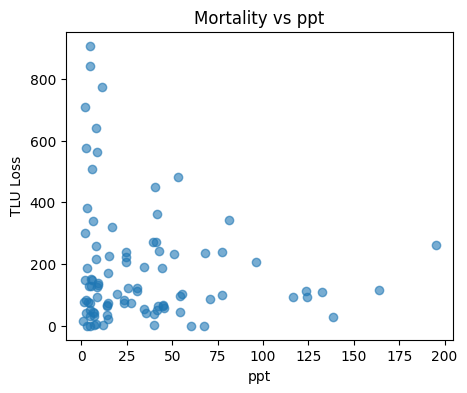

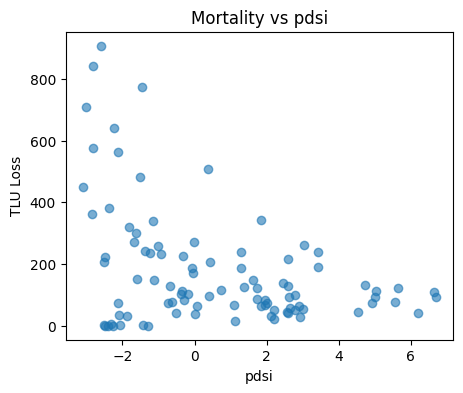

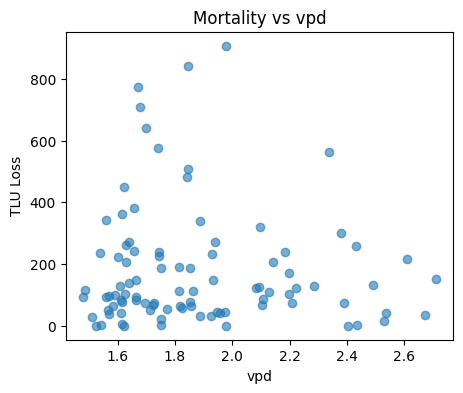

In [65]:
for var in climate_vars:
    plt.figure(figsize=(5,4))
    plt.scatter(data[var], data["tlu_loss"], alpha=0.6)
    plt.xlabel(var)
    plt.ylabel("TLU Loss")
    plt.title(f"Mortality vs {var}")
    plt.show()


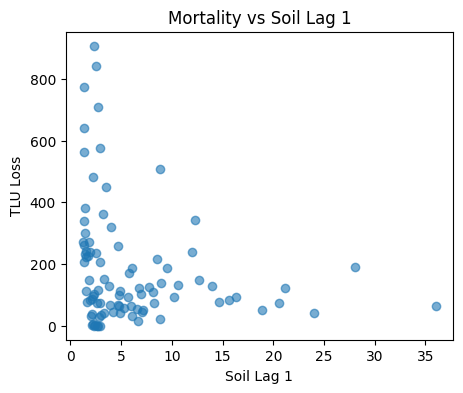

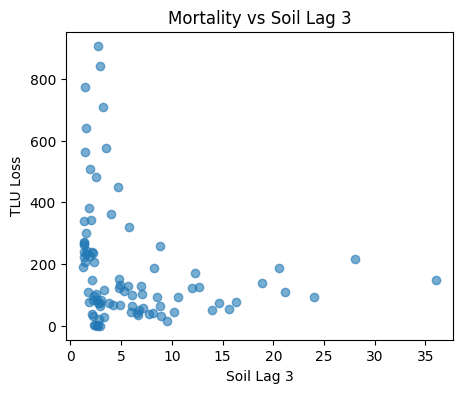

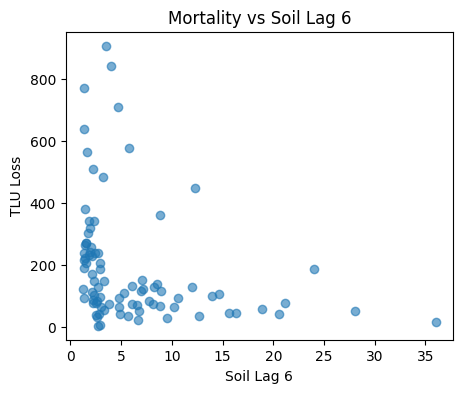

In [66]:
for lag in [1, 3, 6]:
    plt.figure(figsize=(5,4))
    plt.scatter(data[f"soil_lag_{lag}"], data["tlu_loss"], alpha=0.6)
    plt.xlabel(f"Soil Lag {lag}")
    plt.ylabel("TLU Loss")
    plt.title(f"Mortality vs Soil Lag {lag}")
    plt.show()


/var/folders/m6/t8891b6n387709tqj500t0z00000gn/T/ipykernel_12847/3288987017.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


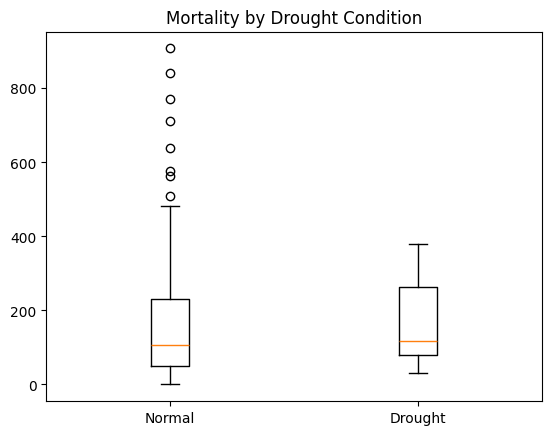

In [67]:
plt.boxplot(
    [
        data[data["dry_signal"] == False]["tlu_loss"],
        data[data["dry_signal"] == True]["tlu_loss"]
    ],
    labels=["Normal", "Drought"]
)

plt.title("Mortality by Drought Condition")
plt.show()


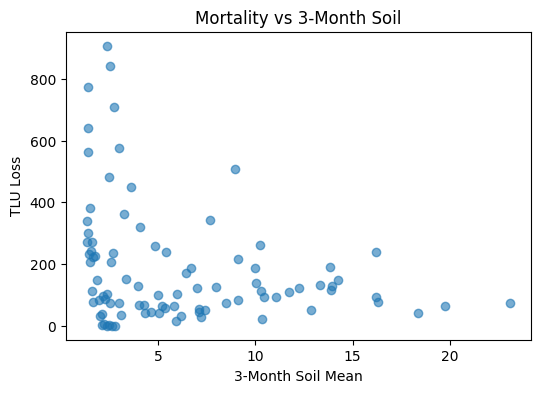

In [68]:
plt.figure(figsize=(6,4))
plt.scatter(data["soil_3mo_mean"], data["tlu_loss"], alpha=0.6)
plt.xlabel("3-Month Soil Mean")
plt.ylabel("TLU Loss")
plt.title("Mortality vs 3-Month Soil")
plt.show()


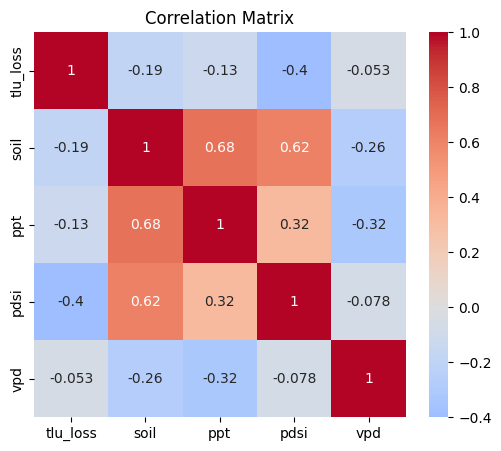

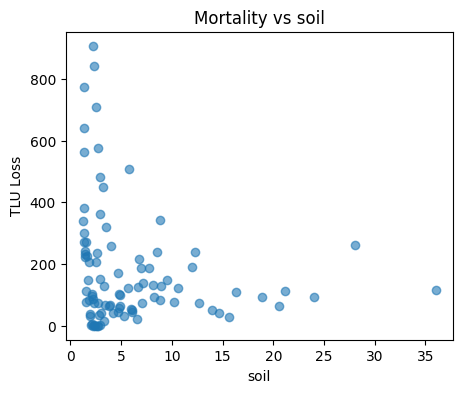

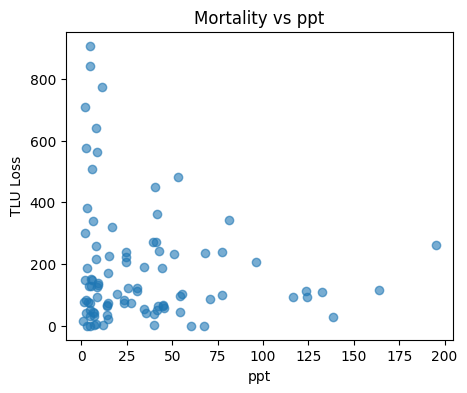

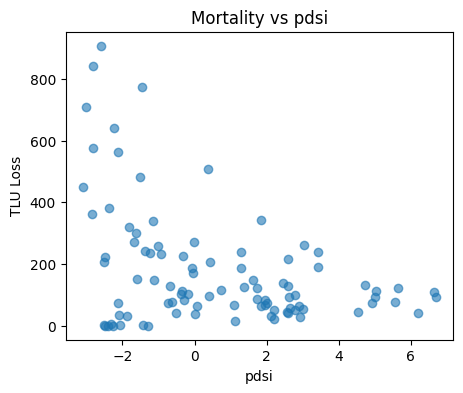

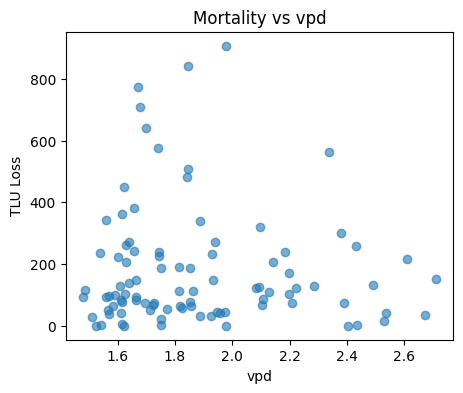

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

climate_vars = ["soil", "ppt", "pdsi", "vpd"]

corr = data[["tlu_loss"] + climate_vars].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

for var in climate_vars:
    plt.figure(figsize=(5,4))
    plt.scatter(data[var], data["tlu_loss"], alpha=0.6)
    plt.xlabel(var)
    plt.ylabel("TLU Loss")
    plt.title(f"Mortality vs {var}")
    plt.show()
